# Linear Regression

What is a *Linear Regression* model? In layman's terms, it is a function that we use to make predictions from data. More precisely, we have input data **x** — which can be a vector of multiple *attributes*, $x = (x_1, x_2, ... , x_n)$ — and an output **y**. The model is a function f(x, w) that approximates y. Given x and y, our goal is to find the optimal parameters **w**.

$$f(x, w) = w_0 + w_1 x_1 + w_2 x_2 + \cdots$$

---

## What Makes People Happy?

> *Spoiler: it's going to be money.*

We will determine the degree of happiness of the global population using information about various characteristics related to well-being, such as the **Gross Domestic Product (GDP)** of the country in which people live, social support, life expectancy, and more.

### First, what atributes do we use?
We'll loade the data and plot a heatmap to chouse data that will be more relevant.

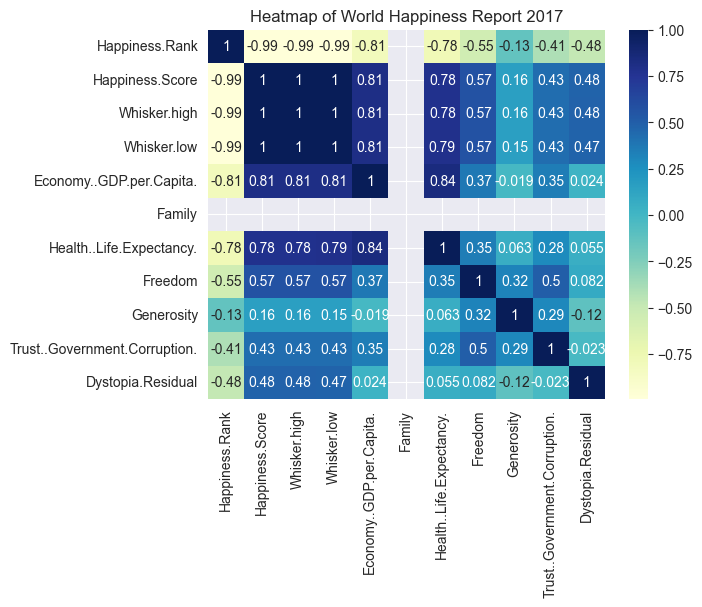

In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

df_v1 = pd.read_csv('data/v1_world-happiness-report-2017.csv')
numeric_df_v1 = df_v1.select_dtypes(include='number')

dataplot = sb.heatmap(numeric_df_v1.corr(), cmap="YlGnBu", annot=True)
plt.title('Heatmap of World Happiness Report 2017')
plt.show()

From this heatmap we can see that theirs a big correlation between _GDP_, _Life Expectancy_ and _Freedom_ so will use this for our model.

Now I hear you asking, *Why is the family column empty?*, well my child it's because they have the same value on evry row because of this the variance is 0 and in the formula that the heatmap uses we can't divide by 0.

$$ r = \frac{cov(X, Y)}{\sigma x * \sigma y} $$

In [2]:
features = ['Economy..GDP.per.Capita.', 'Health..Life.Expectancy.', 'Freedom']
target = 'Happiness.Score'

### Second step!
Now that we have our data we will normalize, and after we will check the linearity. After this we will split the data so that we have training data and testing data. We need to check that the test data is not in a corner, it needs to be spred out.

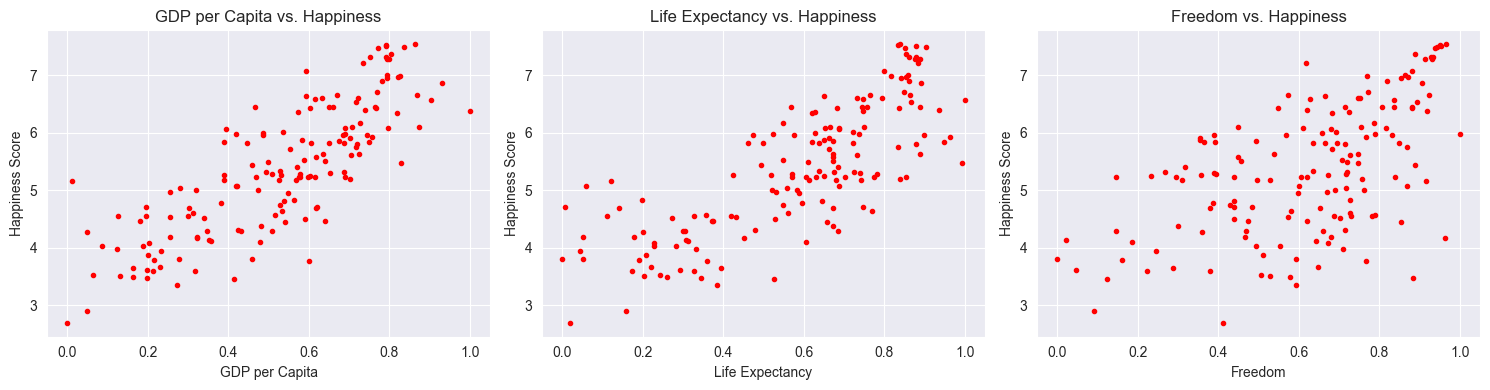

In [3]:
def min_max_normalization(df, key):
    min_val = df[key].min()
    max_val = df[key].max()
    df[key + '_Min'] = [(val - min_val) / (max_val - min_val) for val in df[key]]

min_max_normalization(df_v1, 'Economy..GDP.per.Capita.')
min_max_normalization(df_v1, 'Health..Life.Expectancy.')
min_max_normalization(df_v1, 'Freedom')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature, label in zip(axes, features, ['GDP per Capita', 'Life Expectancy', 'Freedom']):
    ax.plot(df_v1[feature + "_Min"], df_v1['Happiness.Score'], 'ro', markersize=3)
    ax.set_xlabel(label)
    ax.set_ylabel('Happiness Score')
    ax.set_title(f'{label} vs. Happiness')

plt.tight_layout()
plt.show()

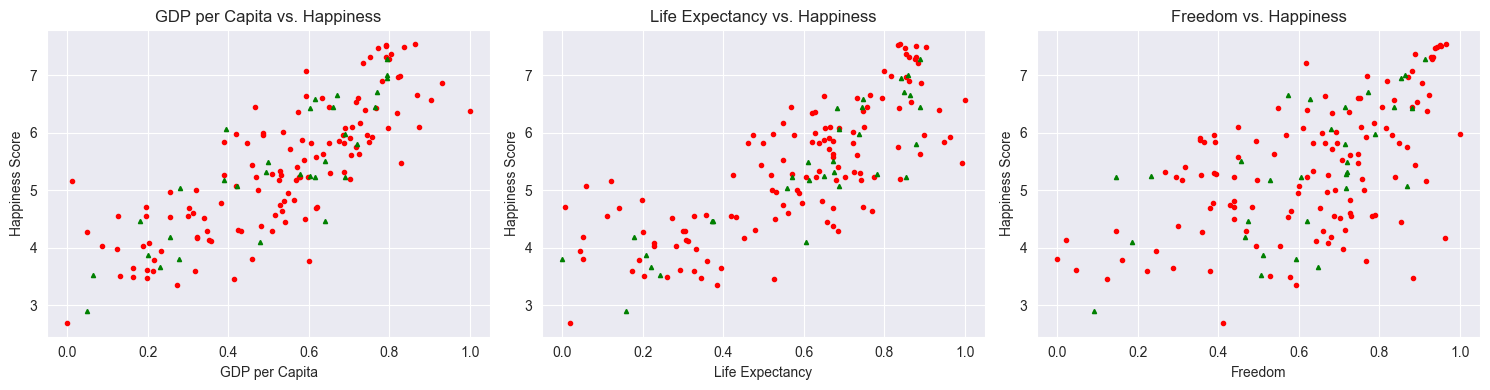

In [4]:
X_v1 = df_v1[[feature + "_Min" for feature in features]]
Y_v1 = df_v1[target]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X_v1, Y_v1, test_size=0.2, random_state=42)

# now well polt to se the spred of the test data, we want it to be all over the place.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature, label in zip(axes, features, ['GDP per Capita', 'Life Expectancy', 'Freedom']):
    ax.plot(x_train[feature + "_Min"], y_train, 'ro', markersize=3)
    ax.plot(x_test[feature + "_Min"], y_test, 'g^', markersize=3)
    ax.set_xlabel(label)
    ax.set_ylabel('Happiness Score')
    ax.set_title(f'{label} vs. Happiness')

plt.tight_layout()
plt.show()

### Least squares
> [wiki](https://en.wikipedia.org/wiki/Least_squares)

In regression analysis, least squares is a method to determine the best-fit model by minimizing the sum of the squared residuals—the differences between observed values and the values predicted by the model. <br>
The fit of a model to a data point is measured by its residual, defined as the difference between the observed value of the dependent variable and the value predicted by the model: $$ r_i = y_i - f(x_i, w) $$

In [5]:
from sklearn import linear_model

regressor = linear_model.LinearRegression()
regressor.fit(x_train, y_train)
w0 = regressor.intercept_
w1, w2, w3 = regressor.coef_
print(f"The learnt model: f(x) = {w0:.4f} + x1 * {w1:.4f} + x2 * {w2:.4f} + x3 * {w3:.4f}")

The learnt model: f(x) = 2.5242 + x1 * 2.4127 + x2 * 1.1446 + x3 * 1.4341


### Last step! See what we've made
Now that we have the mode is time to put the test data into it and see what predictions it makes. We will plot this predictions. After we'll see some the industry standard errors: <br>
+ the absolute difference ($L_1$): $$ Error = \frac{1}{n} * \sum_{i=1}^{n}|y^i - y^i_c| = Mean Absolut Error (MAE) $$
+ the square difference ($L_2$): $$ Error = \sqrt{ \frac{1}{n} * \sum_{i=1}^{n}(y^i - y^i_c)^2} = Root Mean Square Error (RMSE) $$

The prediction MAE: 0.3332
The prediction RMSE: 0.4058


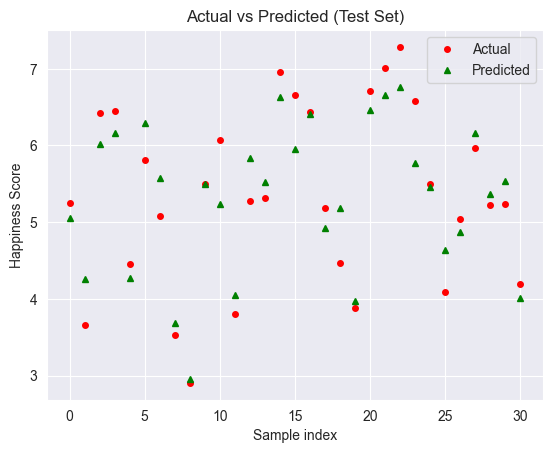

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

predictions = regressor.predict(x_test)
mae_v1 = mean_absolute_error(y_test, predictions)
rmse_v1 = mean_squared_error(y_test, predictions) ** 0.5

print(f"The prediction MAE: {mae_v1:.4f}")
print(f"The prediction RMSE: {rmse_v1:.4f}")

plt.plot(y_test.values, 'ro', markersize=4, label='Actual')
plt.plot(predictions, 'g^', markersize=4, label='Predicted')
plt.xlabel('Sample index')
plt.ylabel('Happiness Score')
plt.title('Actual vs Predicted (Test Set)')
plt.legend()
plt.show()

### Is this good?
Well, a MAE of 0.33 manes we're on average off by 0.33 so if the Happiness score is between [0, 1] is BAD, but if it between [0, 100] it's GREAT. We can see that the std of the madel is 1.13 that means that the model is BETTER than just guessing (because the MAE < std). Also the average is 5.35 so that means our guess with an error of 0.33 are close like... 5 is close to 5.35! :))

In [7]:
df_v1['Happiness.Score'].describe()

count    155.000000
mean       5.354019
std        1.131230
min        2.693000
25%        4.505500
50%        5.279000
75%        6.101500
max        7.537000
Name: Happiness.Score, dtype: float64

# Liniar regression on all the sets again
If you've been reading this homework, aka my **mad thoughts**, thank you. All from abouve was not relevent for the homeowrk. We'll have to do all of this form start.

Well do a liniar regresion with one atribute, that beeing the _Family_ status and also _GDB_ ,status and one with two atribuest, the _GDP_ and _Freedom_. Is this redundant and repetitive? YES! But that's ok. To make this go faster I'll make a class that will just do everything for me :))

[1 feature] MAE: 0.9301, RMSE: 1.1398
Model: f(x) = 5.3544 + x * 0.0000


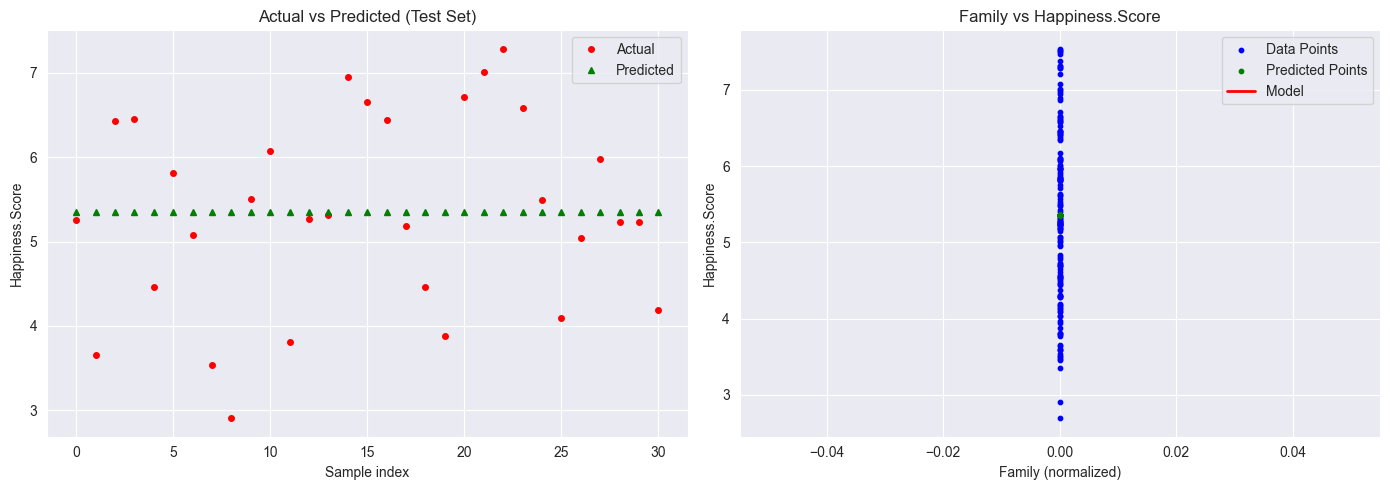

In [8]:
from LRClass import LRClass

lr_classifier = LRClass(
  file_path='data/v1_world-happiness-report-2017.csv',
  target_col='Happiness.Score',
  feature_col_one='Family',
  feature_col_two='Freedom',
  feature_cols=['Economy..GDP.per.Capita.', 'Freedom']
)

lr_classifier.train_feature_one()
lr_classifier.plot_feature_one()

0
[1 feature] MAE: 0.7619, RMSE: 0.8932
Model: f(x) = 3.6619 + x * 2.7175


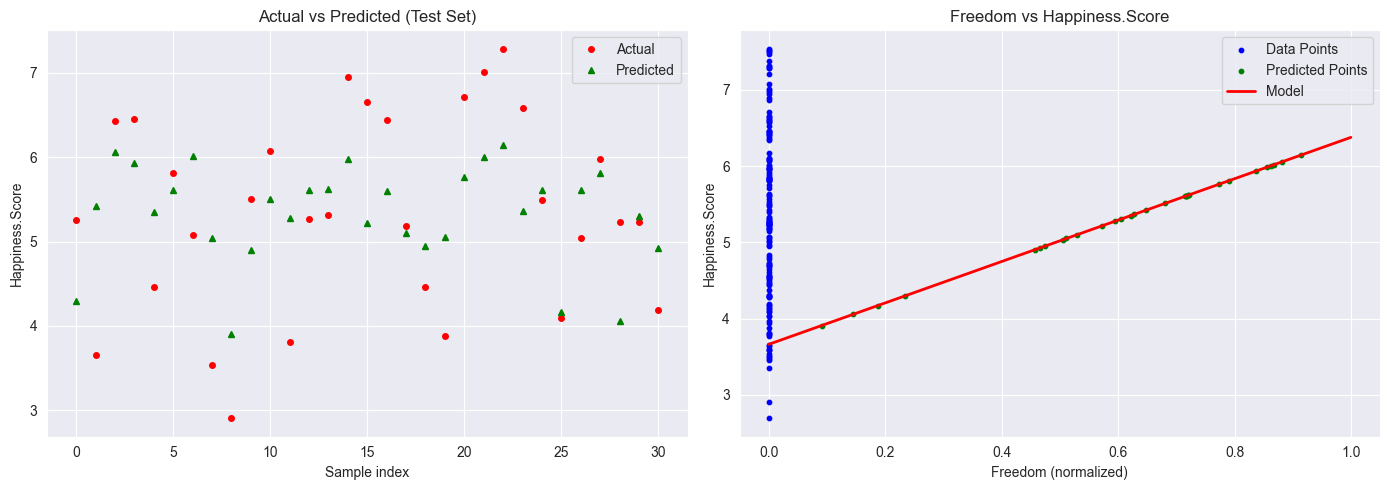

In [9]:
lr_classifier.train_feature_two()
lr_classifier.plot_feature_two()

[2 features] MAE: 0.3758, RMSE: 0.4800
Model: f(x) = 2.6001 + x1 * 3.4614 + x2 * 1.4765


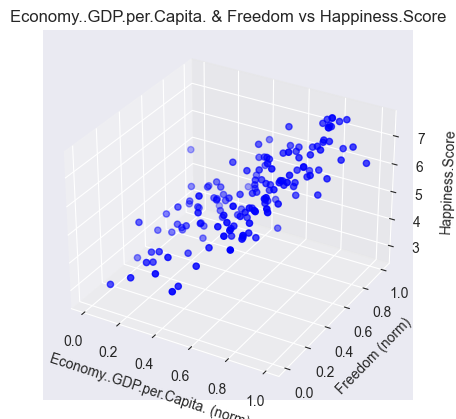

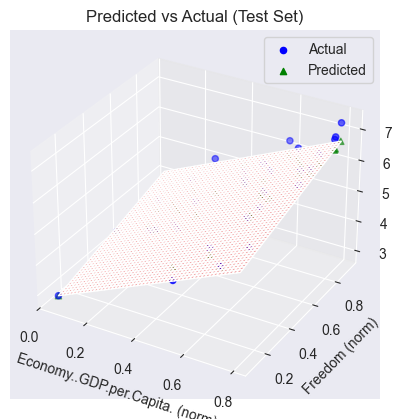

In [10]:
lr_classifier.train_two_features()
lr_classifier.plot_two_features_scatter()
lr_classifier.plot_two_features_predictions()

[1 feature] MAE: 0.6730, RMSE: 0.8110
Model: f(x) = 1.9177 + x * 4.7029


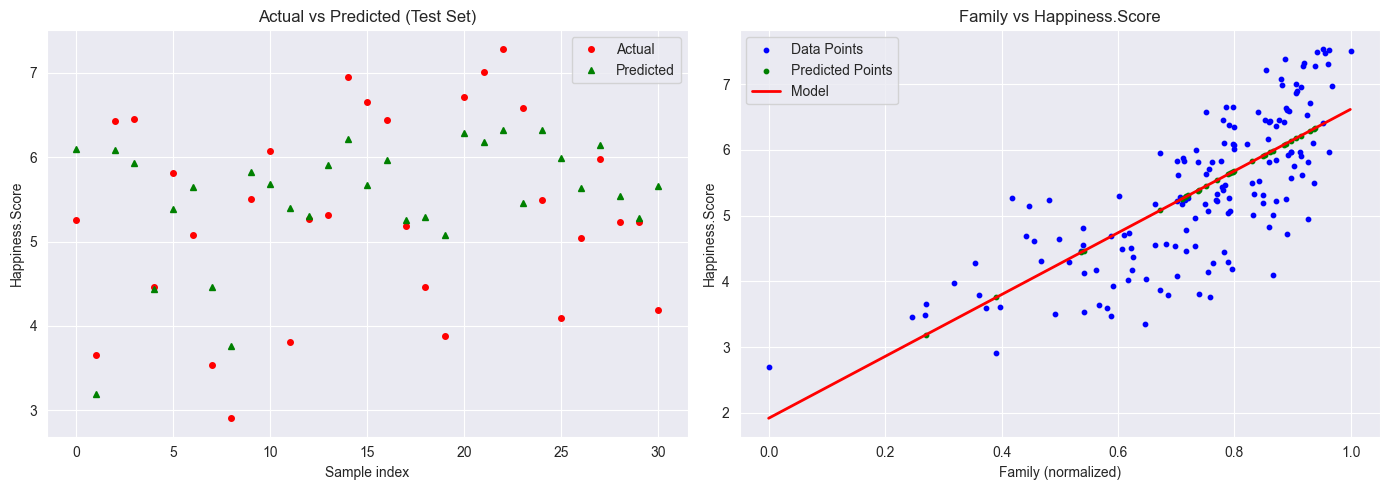

In [11]:
lr_classifier = LRClass(
  file_path='data/v2_world-happiness-report-2017.csv',
  target_col='Happiness.Score',
  feature_col_one='Family',
  feature_col_two='Freedom',
  feature_cols=['Economy..GDP.per.Capita.', 'Freedom']
)

lr_classifier.train_feature_one()
lr_classifier.plot_feature_one()

0
[1 feature] MAE: 0.5032, RMSE: 0.6045
Model: f(x) = 3.2263 + x * 4.0149


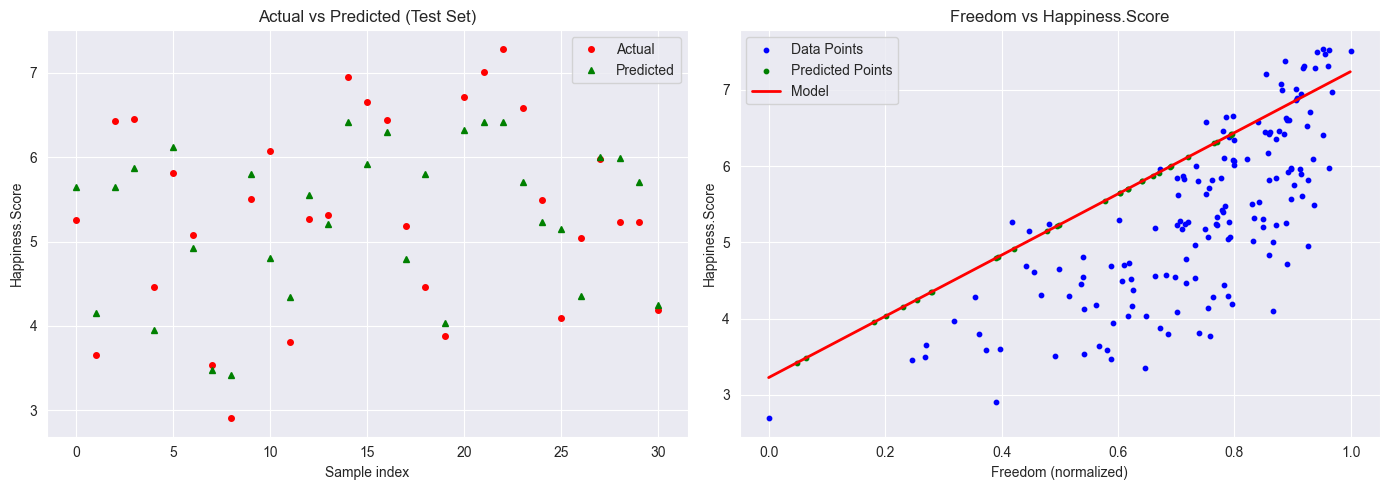

In [12]:
lr_classifier.train_feature_two()
lr_classifier.plot_feature_two()

[2 features] MAE: 0.5108, RMSE: 0.6069
Model: f(x) = 3.2274 + x1 * 43952592.2428 + x2 * -43952588.2299


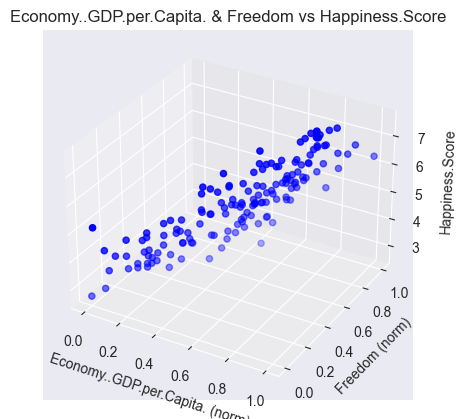

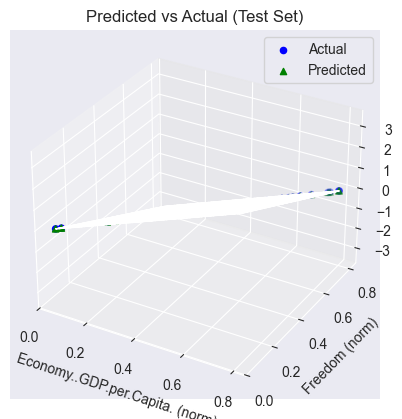

In [13]:
lr_classifier.train_two_features()
lr_classifier.plot_two_features_scatter()
lr_classifier.plot_two_features_predictions()

[1 feature] MAE: 0.6730, RMSE: 0.8110
Model: f(x) = 1.9177 + x * 4.7029


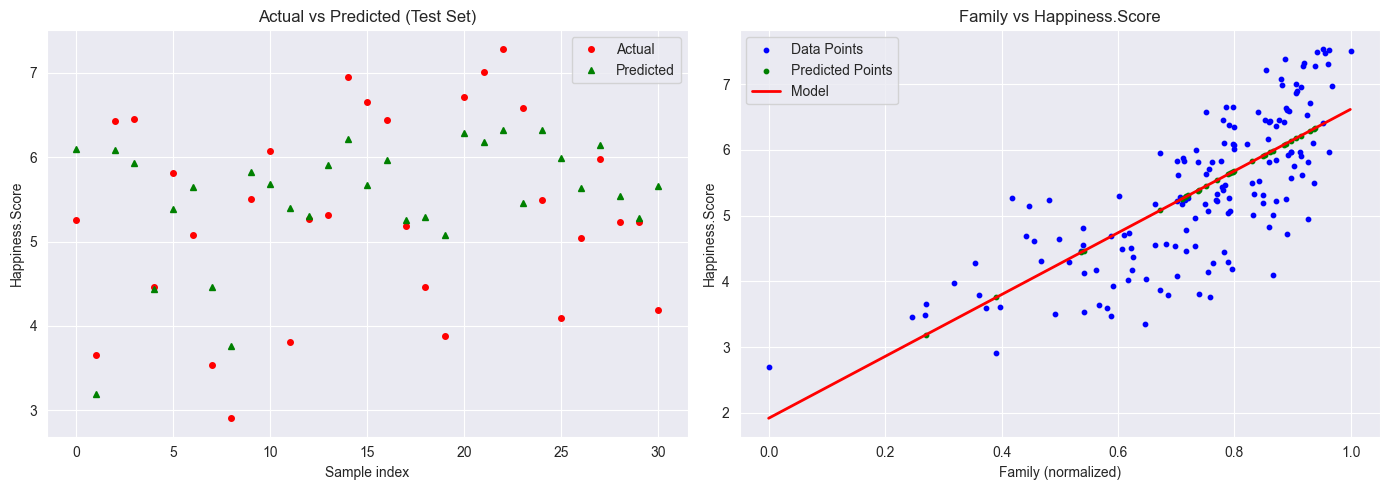

In [14]:
lr_classifier = LRClass(
  file_path='data/v3_world-happiness-report-2017.csv',
  target_col='Happiness.Score',
  feature_col_one='Family',
  feature_col_two='Freedom',
  feature_cols=['Economy..GDP.per.Capita.', 'Freedom']
)

lr_classifier.train_feature_one()
lr_classifier.plot_feature_one()

3
[1 feature] MAE: 0.7977, RMSE: 0.9686
Model: f(x) = 3.5879 + x * 2.9208


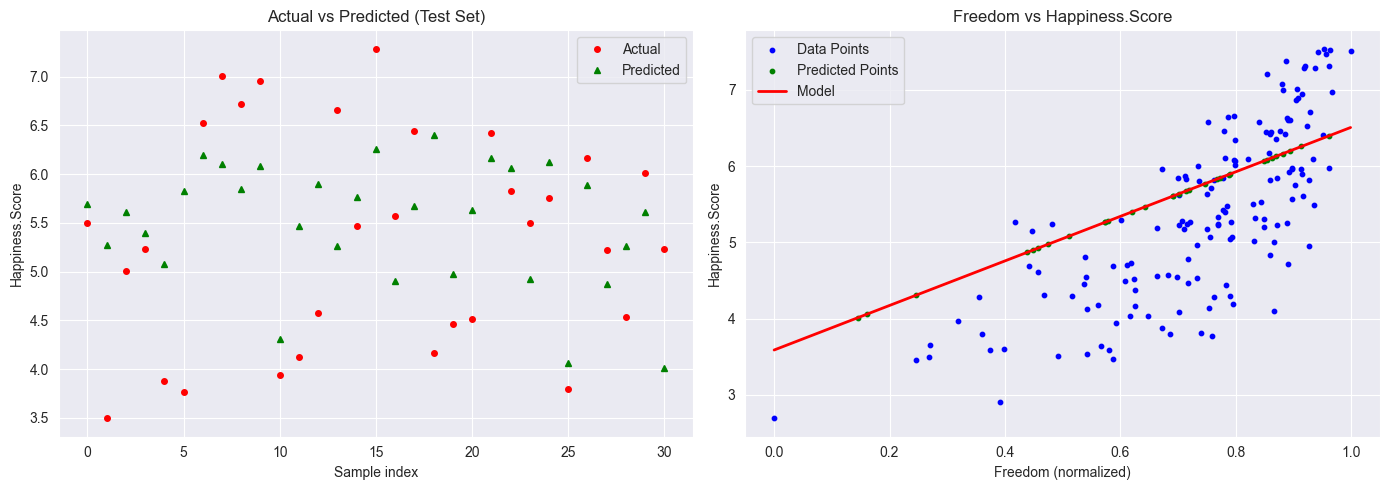

In [15]:
lr_classifier.train_feature_two()
lr_classifier.plot_feature_two()

[2 features] MAE: 0.4391, RMSE: 0.5982
Model: f(x) = 2.5397 + x1 * 3.1622 + x2 * 1.7291


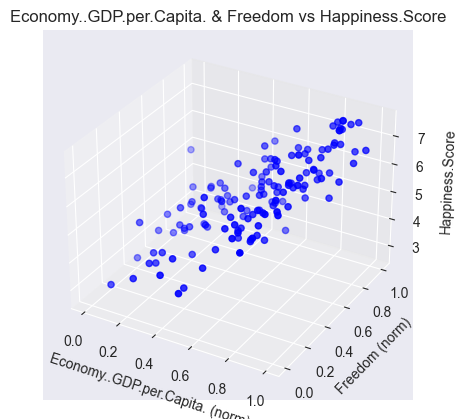

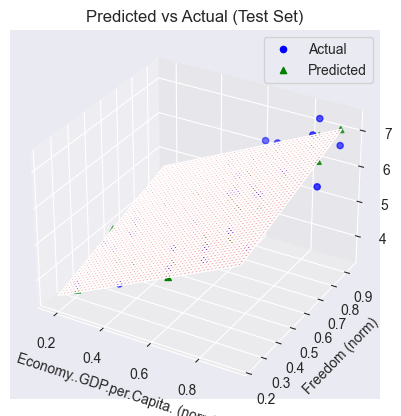

In [16]:
lr_classifier.train_two_features()
lr_classifier.plot_two_features_scatter()
lr_classifier.plot_two_features_predictions()